In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
data_path = "C:/Users/shubh/Downloads/final_dataset.csv"
data = pd.read_csv(data_path)
data.head()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,1,2021,0,5,408.80,442.42,160.61,12.95,2.77,43.19,462
1,2,1,2021,0,6,404.04,561.95,52.85,5.18,2.60,16.43,482
2,3,1,2021,1,7,225.07,239.04,170.95,10.93,1.40,44.29,263
3,4,1,2021,0,1,89.55,132.08,153.98,10.42,1.01,49.19,207
4,5,1,2021,0,2,54.06,55.54,122.66,9.70,0.64,48.88,149


In [3]:
# EDA
print("Missing values per column:\n", data.isnull().sum())
for col in data.select_dtypes(include=[np.number]).columns:
    data[col] = data[col].fillna(data[col].median())

Missing values per column:
 Date              0
Month             0
Year              0
Holidays_Count    0
Days              0
PM2.5             0
PM10              0
NO2               0
SO2               0
CO                0
Ozone             0
AQI               0
dtype: int64


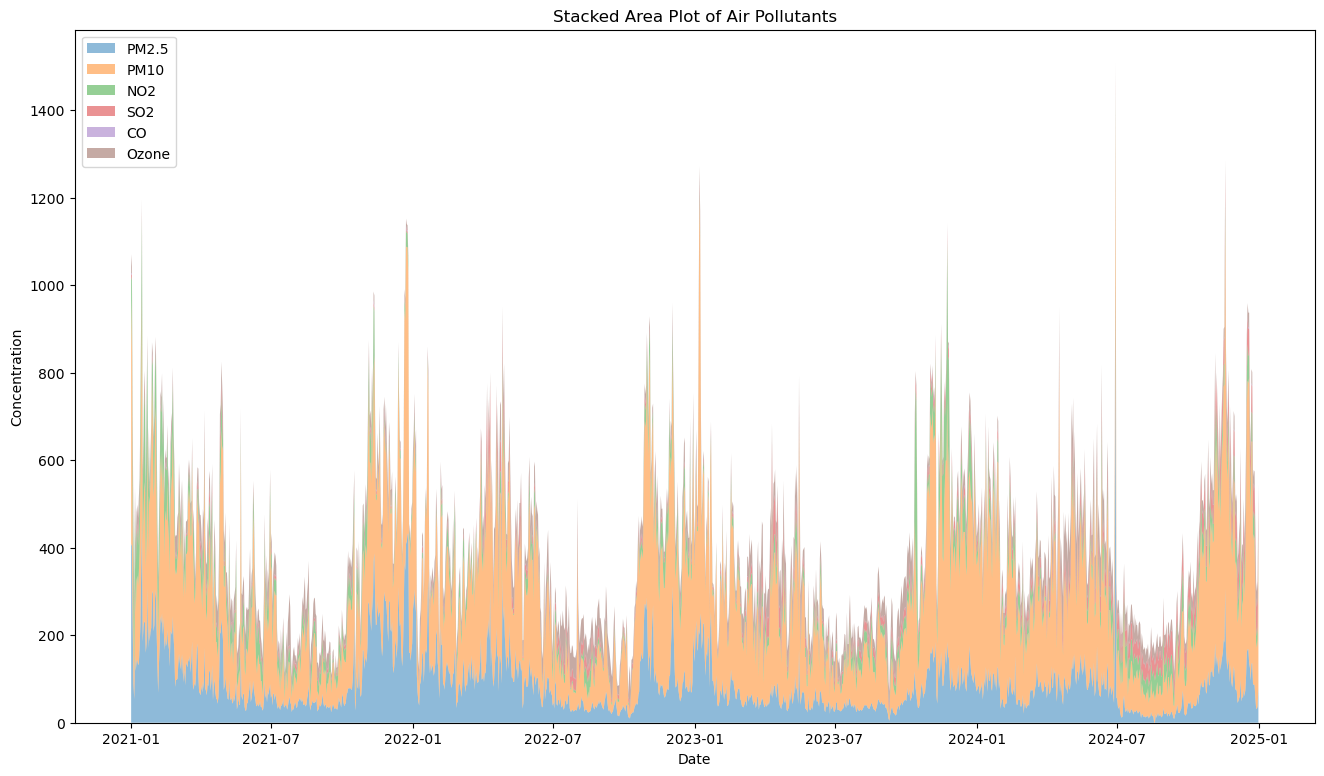

In [4]:
if {'Year', 'Month', 'Date'}.issubset(data.columns):
    dates = pd.to_datetime(dict(year=data['Year'], month=data['Month'], day=data['Date']), errors='coerce')
else:
    dates = pd.to_datetime(data['Date'], errors='coerce')
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']
plt.figure(figsize=(16, 9))
plt.title('Stacked Area Plot of Air Pollutants')
plt.stackplot(dates, *[data[p] for p in pollutants], alpha=0.5)
plt.legend(pollutants, loc='upper left')
plt.xlabel('Date')
plt.ylabel('Concentration')
plt.show()

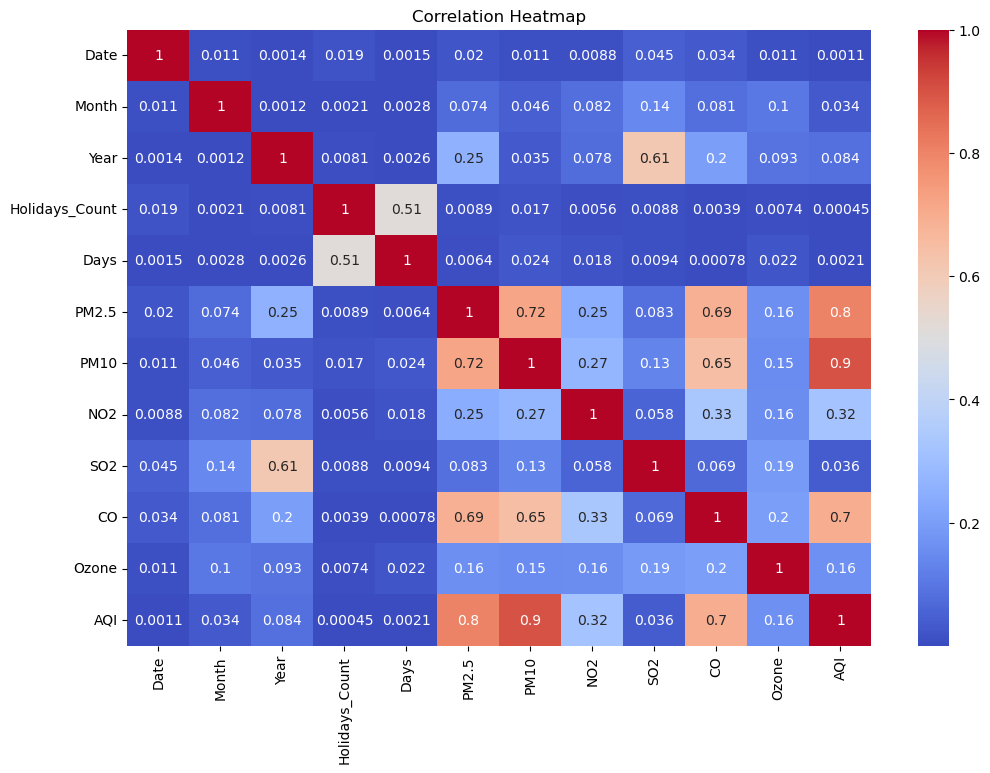

In [5]:
# 4. EDA: Correlation & Feature Selection
corr_matrix = data.corr().abs()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

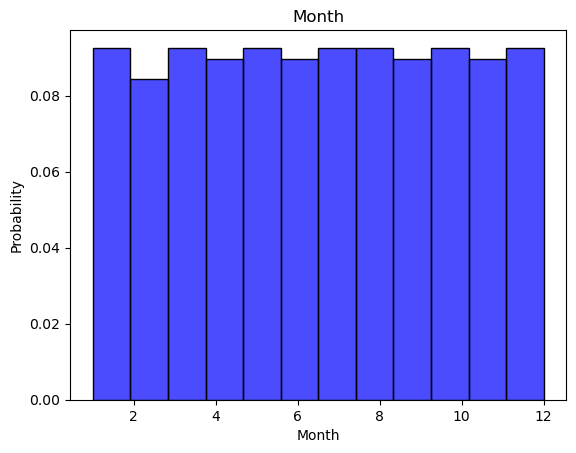

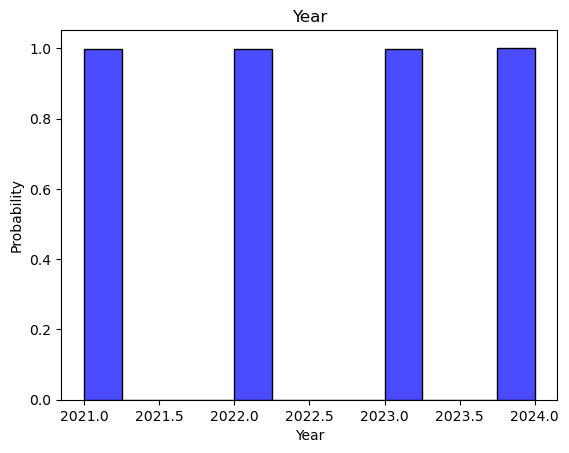

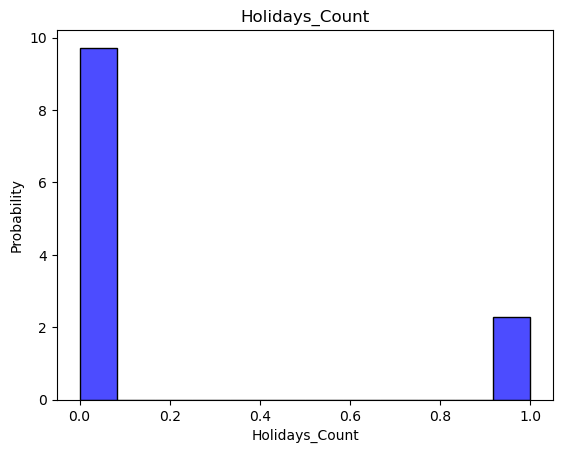

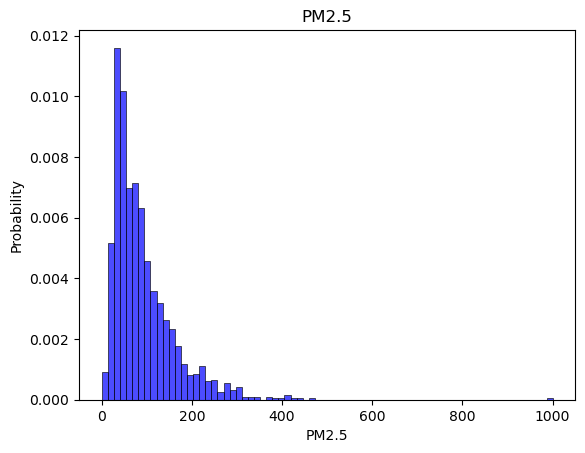

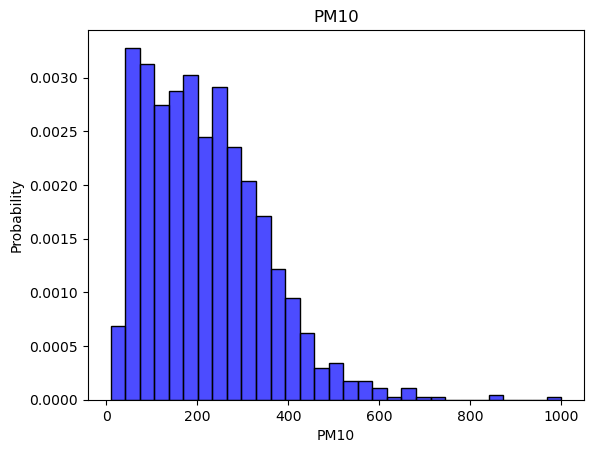

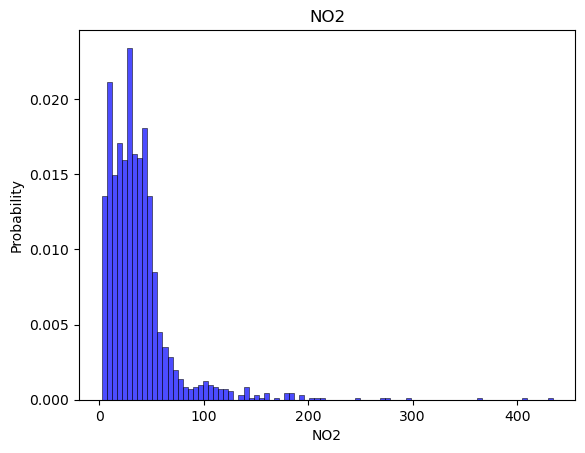

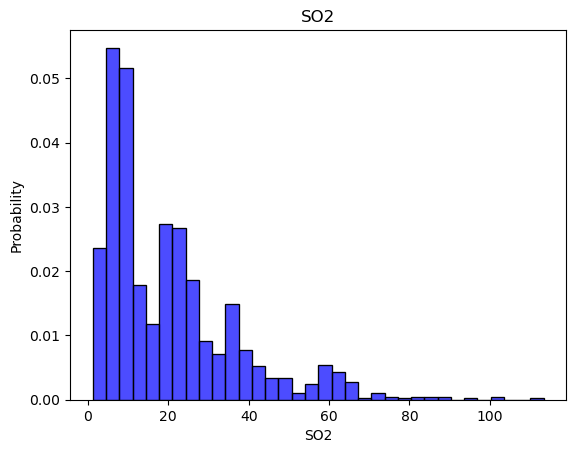

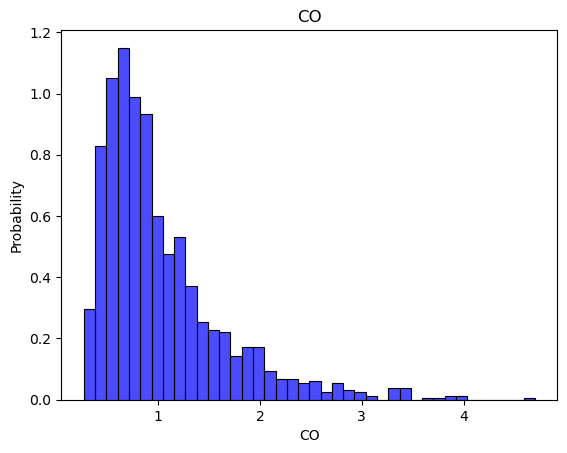

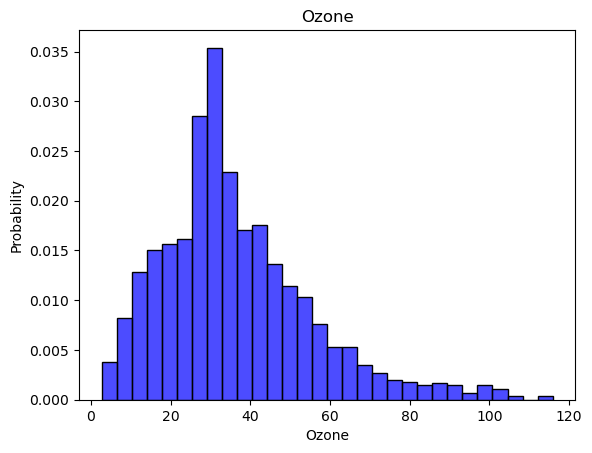

In [20]:
feature_columns = list(X_train.columns)

for label in feature_columns:
    sns.histplot(data[label], color="blue", stat="density", alpha=0.7)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)
    plt.show()

In [13]:
# Removing highly correlated features (threshold > 0.95)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print("Dropping highly correlated columns:", to_drop)
data = data.drop(columns=to_drop)

Dropping highly correlated columns: []


In [14]:
# Droping non-numeric and irrelevant columns
drop_cols = ['Date', 'Day_type', 'Days'] if 'Days' in data.columns else ['Date', 'Day_type']
data = data.drop(columns=[col for col in drop_cols if col in data.columns])

In [15]:
#  Splitting Data
X = data.drop('AQI', axis=1)
y = data['AQI']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [16]:
# Exclude AQI column and get feature count
feature_columns = list(X_train.columns)
print("Number of input features:", len(feature_columns))
print("Feature names:", feature_columns)

Number of input features: 9
Feature names: ['Month', 'Year', 'Holidays_Count', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']


In [17]:
# Scaling Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)



In [18]:
# Model Selection & Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
gbr = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gbr, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R2 score:", grid_search.best_score_)


Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best cross-validated R2 score: 0.9064540002945668


In [19]:
# Evaluate on Validation and Test Sets
gbr_model = grid_search.best_estimator_
y_valid_pred = gbr_model.predict(X_valid_scaled)
y_test_pred = gbr_model.predict(X_test_scaled)

print("Validation R2 Score:", r2_score(y_valid, y_valid_pred))
print("Test R2 Score:", r2_score(y_test, y_test_pred))
print("Validation MSE:", mean_squared_error(y_valid, y_valid_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))



Validation R2 Score: 0.9364194612743967
Test R2 Score: 0.9334882185409445
Validation MSE: 763.3461485888716
Test MSE: 828.0366231356134


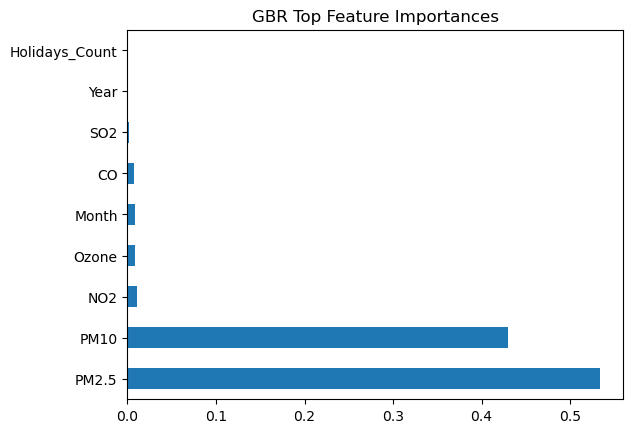

In [ ]:
# Feature Importance Plot for GRADIENT BOOSTING REGRESSOR
feat_importances = pd.Series(gbr_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("GBR Top Feature Importances")
plt.show()



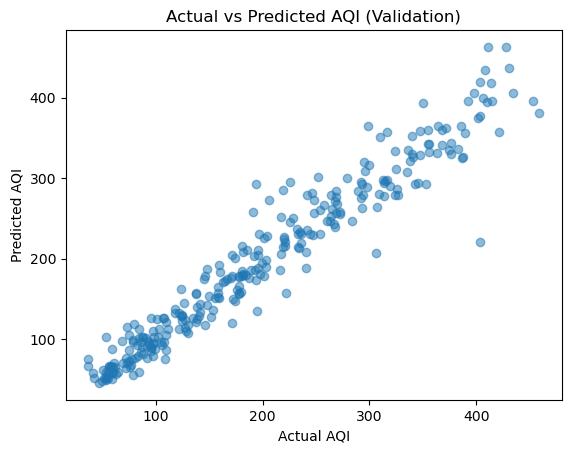

In [ ]:
# Residual Plot
plt.scatter(y_valid, y_valid_pred, alpha=0.5)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Validation)")
plt.show()

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=3, scoring='r2', n_jobs=-1)
grid_search_xgb.fit(X_train_scaled, y_train)

print("XGBoost Best parameters:", grid_search_xgb.best_params_)
print("XGBoost Best cross-validated R2 score:", grid_search_xgb.best_score_)

best_xgb = grid_search_xgb.best_estimator_
y_valid_pred_xgb = best_xgb.predict(X_valid_scaled)
y_test_pred_xgb = best_xgb.predict(X_test_scaled)

print("XGBoost Validation R2 Score:", r2_score(y_valid, y_valid_pred_xgb))
print("XGBoost Test R2 Score:", r2_score(y_test, y_test_pred_xgb))
print("XGBoost Validation MSE:", mean_squared_error(y_valid, y_valid_pred_xgb))
print("XGBoost Test MSE:", mean_squared_error(y_test, y_test_pred_xgb))



XGBoost Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
XGBoost Best cross-validated R2 score: 0.9071954091389974
XGBoost Validation R2 Score: 0.9424105882644653
XGBoost Test R2 Score: 0.9361819624900818
XGBoost Validation MSE: 691.41650390625
XGBoost Test MSE: 794.5010375976562


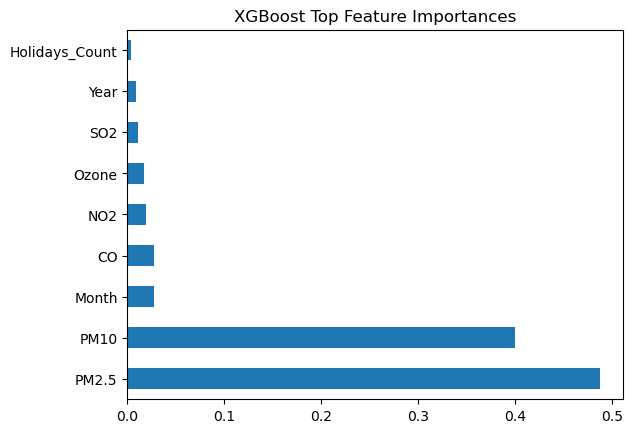

In [ ]:
# Feature Importance Plot for XGBOOST
feat_importances_xgb = pd.Series(best_xgb.feature_importances_, index=X.columns)
feat_importances_xgb.nlargest(10).plot(kind='barh')
plt.title("XGBoost Top Feature Importances")
plt.show()